In [19]:
# =============================================================================
# RETAIL SALES FORECASTING - REGRESSION ANALYSIS
# Dataset: mock_kaggle.csv
# Columns in source dataset:
#   data    -> Date
#   venda   -> Sales
#   estoque -> Stock
#   preco   -> Price
# =============================================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [20]:
# -----------------------------------------------------------------------------
# STEP 1. DATA LOADING
# -----------------------------------------------------------------------------
FILE_PATH = "mock_kaggle.csv"

df = pd.read_csv(FILE_PATH)

print("=" * 80)
print("STEP 1 - DATA LOADING")
print("=" * 80)
print("Shape:", df.shape)
print(df.head())

STEP 1 - DATA LOADING
Shape: (937, 4)
         data  venda  estoque  preco
0  2014-01-01      0     4972   1.29
1  2014-01-02     70     4902   1.29
2  2014-01-03     59     4843   1.29
3  2014-01-04     93     4750   1.29
4  2014-01-05     96     4654   1.29


---

## Step 1 - Data Loading
Load the CSV file using Pandas.

```python
df = pd.read_csv("mock_kaggle.csv")
```

The uploaded dataset contains:

| Original Column | Meaning |
|---|---|
| `data` | Date |
| `venda` | Sales |
| `estoque` | Stock |
| `preco` | Price |

---

In [21]:
# -----------------------------------------------------------------------------
# STEP 2. DATA UNDERSTANDING
# -----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("STEP 2 - DATA UNDERSTANDING")
print("=" * 80)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDataset information:")
df.info()

print("\nDescriptive statistics:")
print(df.describe())


STEP 2 - DATA UNDERSTANDING

Columns:
['data', 'venda', 'estoque', 'preco']

Data types:
data        object
venda        int64
estoque      int64
preco      float64
dtype: object

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 937 entries, 0 to 936
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     937 non-null    object 
 1   venda    937 non-null    int64  
 2   estoque  937 non-null    int64  
 3   preco    937 non-null    float64
dtypes: float64(1), int64(2), object(1)
memory usage: 29.4+ KB

Descriptive statistics:
            venda      estoque       preco
count  937.000000   937.000000  937.000000
mean    90.533618  1608.258271    1.592572
std     80.682089  1356.691877    0.529502
min      0.000000     0.000000    0.000000
25%     33.000000   794.000000    1.290000
50%     76.000000  1348.000000    1.390000
75%    127.000000  1964.000000    1.890000
max    542.000000  7228.000000    

---

## Step 2 - Data Understanding
Inspect:
- Number of rows and columns
- Column names
- Data types
- Summary statistics
- Dataset information

This step helps understand the structure and quality of the data before analysis.

---

In [22]:
# -----------------------------------------------------------------------------
# STEP 3. DATA CLEANING
# -----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("STEP 3 - DATA CLEANING")
print("=" * 80)

df.columns = df.columns.str.strip()

# Rename source columns to English names for readability
column_mapping = {
    "data": "Date",
    "venda": "Sales",
    "estoque": "Stock",
    "preco": "Price"
}
df = df.rename(columns=column_mapping)

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

for col in ["Sales", "Stock", "Price"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("\nMissing values before cleaning:")
print(df.isnull().sum())

# Remove invalid rows and duplicates
df = df.dropna(subset=["Date", "Sales", "Stock", "Price"])
df = df.drop_duplicates()

# Sales, stock and price cannot be negative
df = df[(df["Sales"] >= 0) & (df["Stock"] >= 0) & (df["Price"] >= 0)]

df = df.sort_values("Date").reset_index(drop=True)

print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\nCleaned shape:", df.shape)
print("Date range:", df["Date"].min().date(), "to", df["Date"].max().date())


STEP 3 - DATA CLEANING

Missing values before cleaning:
Date     0
Sales    0
Stock    0
Price    0
dtype: int64

Missing values after cleaning:
Date     0
Sales    0
Stock    0
Price    0
dtype: int64

Cleaned shape: (937, 4)
Date range: 2014-01-01 to 2016-07-31


---

## Step 3 - Data Cleaning
The program:
- Removes spaces from column names
- Renames columns into readable English names
- Converts `Date` to datetime
- Converts numerical columns to numeric values
- Checks missing values
- Removes duplicate rows
- Removes invalid negative sales, stock, and price values
- Sorts records chronologically

---

In [23]:
# -----------------------------------------------------------------------------
# STEP 4. FEATURE ENGINEERING
# -----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("STEP 4 - FEATURE ENGINEERING")
print("=" * 80)

# Calendar features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["DayOfMonth"] = df["Date"].dt.day
df["Quarter"] = df["Date"].dt.quarter

# Lag features use only previous observations.
df["Sales_Lag_1"] = df["Sales"].shift(1)
df["Sales_Lag_7"] = df["Sales"].shift(7)
df["Sales_Rolling_7"] = df["Sales"].shift(1).rolling(7).mean()

# Previous-day stock and price avoid using future information.
df["Stock_Lag_1"] = df["Stock"].shift(1)
df["Price_Lag_1"] = df["Price"].shift(1)

df_model = df.dropna().copy()

print("Modeling rows:", len(df_model))
print("\nFeature columns:")
print([
    "Sales_Lag_1", "Sales_Lag_7", "Sales_Rolling_7",
    "Stock_Lag_1", "Price_Lag_1",
    "Year", "Month", "DayOfWeek", "DayOfMonth", "Quarter"
])


STEP 4 - FEATURE ENGINEERING
Modeling rows: 930

Feature columns:
['Sales_Lag_1', 'Sales_Lag_7', 'Sales_Rolling_7', 'Stock_Lag_1', 'Price_Lag_1', 'Year', 'Month', 'DayOfWeek', 'DayOfMonth', 'Quarter']


---

## Step 4 - Feature Engineering
New variables are created to help the regression model learn sales patterns.

### Calendar Features
- Year
- Month
- Day of week
- Day of month
- Quarter

### Lag Features
- Previous-day sales
- Sales from 7 days earlier
- Previous 7-day average sales
- Previous-day stock
- Previous-day price

Lag features are important in forecasting because they use historical information rather than future information.

---

In [24]:
# -----------------------------------------------------------------------------
# STEP 5. DESCRIPTIVE ANALYSIS
# -----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("STEP 5 - DESCRIPTIVE ANALYSIS")
print("=" * 80)

print("\nSales statistics:")
print(df["Sales"].describe())

print("\nStock statistics:")
print(df["Stock"].describe())

print("\nPrice statistics:")
print(df["Price"].describe())

print("\nAverage sales by month:")
print(df.groupby("Month")["Sales"].mean().round(2))

print("\nTotal sales by year:")
print(df.groupby("Year")["Sales"].sum())

print("\nTop 10 sales days:")
print(df.nlargest(10, "Sales")[["Date", "Sales", "Stock", "Price"]])


STEP 5 - DESCRIPTIVE ANALYSIS

Sales statistics:
count    937.000000
mean      90.533618
std       80.682089
min        0.000000
25%       33.000000
50%       76.000000
75%      127.000000
max      542.000000
Name: Sales, dtype: float64

Stock statistics:
count     937.000000
mean     1608.258271
std      1356.691877
min         0.000000
25%       794.000000
50%      1348.000000
75%      1964.000000
max      7228.000000
Name: Stock, dtype: float64

Price statistics:
count    937.000000
mean       1.592572
std        0.529502
min        0.000000
25%        1.290000
50%        1.390000
75%        1.890000
max        2.980000
Name: Price, dtype: float64

Average sales by month:
Month
1      95.82
2      81.54
3      84.86
4      90.46
5      81.15
6     131.73
7     100.96
8      53.74
9      82.92
10    108.69
11     77.93
12     79.42
Name: Sales, dtype: float64

Total sales by year:
Year
2014    25257
2015    32234
2016    27339
Name: Sales, dtype: int64

Top 10 sales days:
          

---

## Step 5 - Descriptive Analysis
Descriptive analytics explains **what happened** in the historical data.

The program calculates:
- Mean
- Standard deviation
- Minimum
- Maximum
- Quartiles
- Average sales by month
- Total sales by year
- Highest-sales days

---

In [25]:
# -----------------------------------------------------------------------------
# STEP 6. DIAGNOSTIC ANALYSIS
# -----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("STEP 6 - DIAGNOSTIC ANALYSIS")
print("=" * 80)

analysis_cols = ["Sales", "Stock", "Price", "Sales_Lag_1", "Sales_Lag_7"]
correlation = df_model[analysis_cols].corr()

print("\nCorrelation matrix:")
print(correlation.round(3))


STEP 6 - DIAGNOSTIC ANALYSIS

Correlation matrix:
             Sales  Stock  Price  Sales_Lag_1  Sales_Lag_7
Sales        1.000  0.158  0.095        0.647        0.301
Stock        0.158  1.000 -0.023        0.110        0.057
Price        0.095 -0.023  1.000        0.100        0.158
Sales_Lag_1  0.647  0.110  0.100        1.000        0.273
Sales_Lag_7  0.301  0.057  0.158        0.273        1.000


---

## Step 6 - Diagnostic Analysis
Diagnostic analytics investigates **why patterns may have occurred**.

A correlation matrix is created for:
- Sales
- Stock
- Price
- Previous-day sales
- 7-day lagged sales

Correlation values help identify the strength and direction of linear relationships.

---


STEP 7 - DATA VISUALIZATION


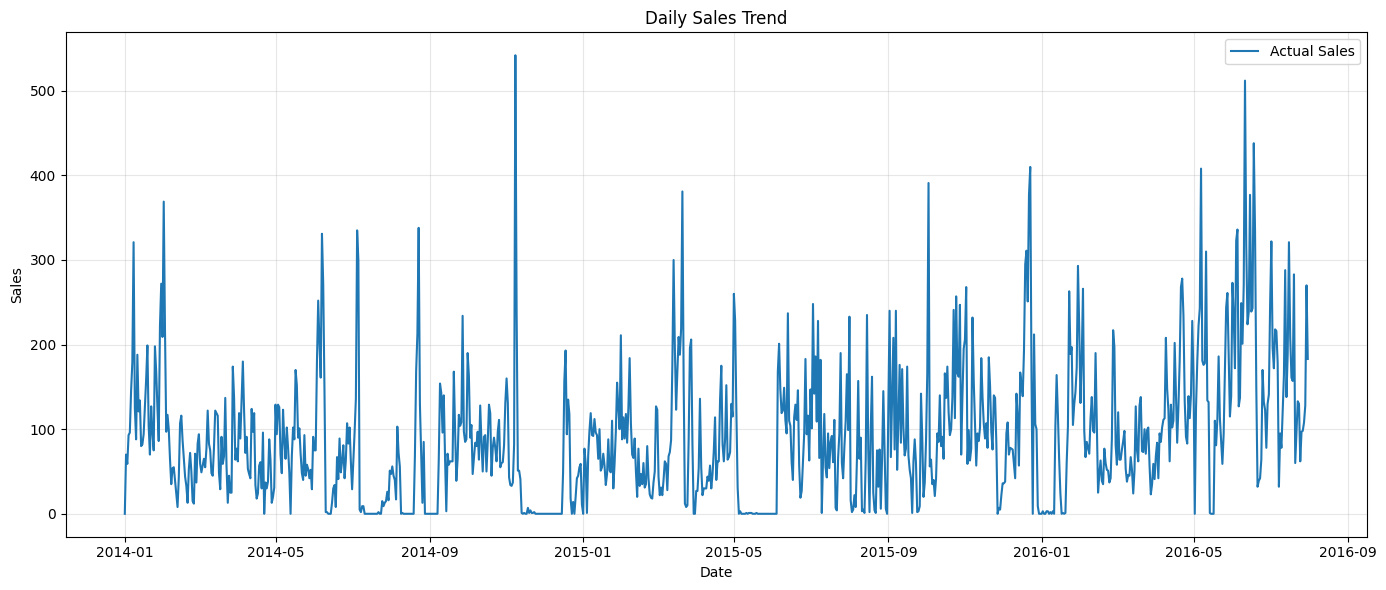

In [26]:
# -----------------------------------------------------------------------------
# STEP 7. TIME-SERIES VISUALIZATION
# -----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("STEP 7 - DATA VISUALIZATION")
print("=" * 80)

plt.figure(figsize=(14, 6))
plt.plot(df["Date"], df["Sales"], label="Actual Sales")
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

---

## Step 7 - Data Visualization
The program creates a daily sales trend chart.

This visualization helps identify:
- Increasing or decreasing sales
- Peaks
- Low-sales periods
- Possible seasonality
- Changes in demand over time

---

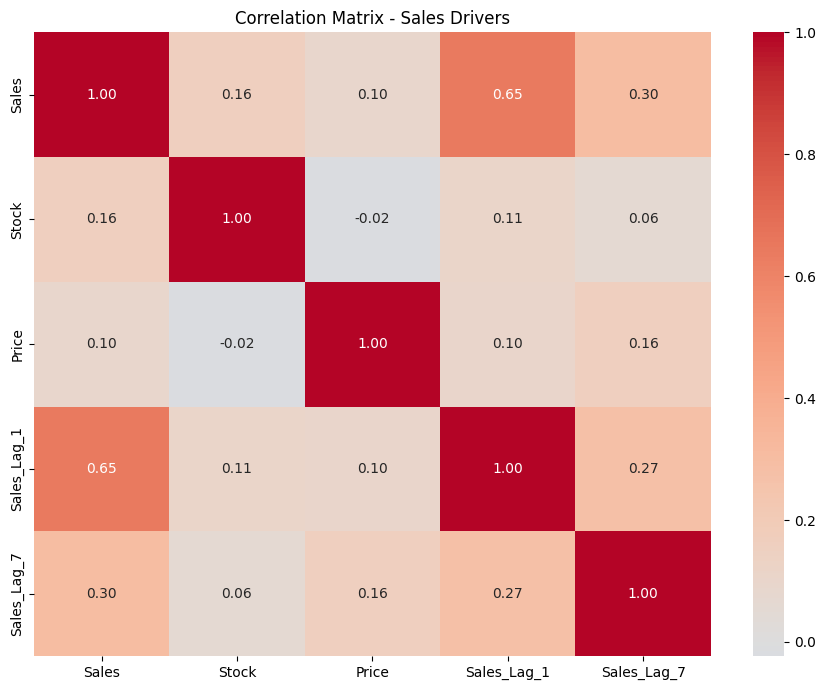

In [27]:
# -----------------------------------------------------------------------------
# STEP 8. CORRELATION HEATMAP
# -----------------------------------------------------------------------------
plt.figure(figsize=(9, 7))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix - Sales Drivers")
plt.tight_layout()
plt.show()

---

## Step 8 - Correlation Visualization
A heatmap displays correlations between important numerical variables.

A value close to:
- `+1` indicates strong positive relationship
- `-1` indicates strong negative relationship
- `0` indicates weak linear relationship

Correlation does not prove causation.

---

In [28]:
# -----------------------------------------------------------------------------
# STEP 9. PREPARE DATA FOR REGRESSION
# -----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("STEP 9 - FEATURE PREPARATION")
print("=" * 80)

features = [
    "Sales_Lag_1",
    "Sales_Lag_7",
    "Sales_Rolling_7",
    "Stock_Lag_1",
    "Price_Lag_1",
    "Year",
    "Month",
    "DayOfWeek",
    "DayOfMonth",
    "Quarter"
]

X = df_model[features]
y = df_model["Sales"]

# Time-series split: do NOT randomly shuffle the data.
split_index = int(len(df_model) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))


STEP 9 - FEATURE PREPARATION
Training rows: 744
Testing rows : 186


---

## Step 9 - Feature Preparation
The model features include historical sales, stock, price, and calendar variables.

The dataset is split chronologically:
- 80% training data
- 20% testing data

Random shuffling is avoided because this is time-series forecasting.

---

In [29]:
# -----------------------------------------------------------------------------
# STEP 10. MACHINE LEARNING - LINEAR REGRESSION
# -----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("STEP 10 - MACHINE LEARNING: LINEAR REGRESSION")
print("=" * 80)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nIntercept:", round(model.intercept_, 4))

coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
}).sort_values("Coefficient", ascending=False)

print("\nRegression coefficients:")
print(coefficients.to_string(index=False))


STEP 10 - MACHINE LEARNING: LINEAR REGRESSION

Intercept: -33641.0017

Regression coefficients:
        Feature  Coefficient
           Year    16.695577
      DayOfWeek     4.088304
        Quarter     3.904002
          Month     0.686026
    Sales_Lag_1     0.488610
Sales_Rolling_7     0.149128
    Stock_Lag_1     0.009927
    Sales_Lag_7     0.007066
     DayOfMonth    -0.246583
    Price_Lag_1    -1.930562


---

## Step 10 - Predictive Analysis / Machine Learning
A **Linear Regression** model is trained.

The general regression equation is:

\[
Sales = b_0 + b_1X_1 + b_2X_2 + ... + b_nX_n
\]

Where:
- `Sales` = predicted sales
- `b0` = intercept
- `b1...bn` = model coefficients
- `X1...Xn` = input features

The coefficients show how each feature is associated with predicted sales while the other model variables are held constant.

---

In [30]:
# -----------------------------------------------------------------------------
# STEP 11. MODEL EVALUATION
# -----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("STEP 11 - MODEL EVALUATION")
print("=" * 80)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")


STEP 11 - MODEL EVALUATION
MAE  : 48.47
RMSE : 65.00
R²   : 0.4777


---

## Step 11 - Model Evaluation
The model is evaluated using:

### MAE
Mean Absolute Error measures the average absolute prediction error.

\[
MAE = \frac{1}{n}\sum |y_i-\hat{y_i}|
\]

Lower MAE is better.

### RMSE
Root Mean Squared Error gives more weight to larger errors.

\[
RMSE = \sqrt{\frac{1}{n}\sum(y_i-\hat{y_i})^2}
\]

Lower RMSE is better.

### R²
R-squared measures how much variation in the target is explained by the model.

\[
R^2 = 1-\frac{SS_{res}}{SS_{tot}}
\]

A value closer to 1 generally indicates better fit.

---

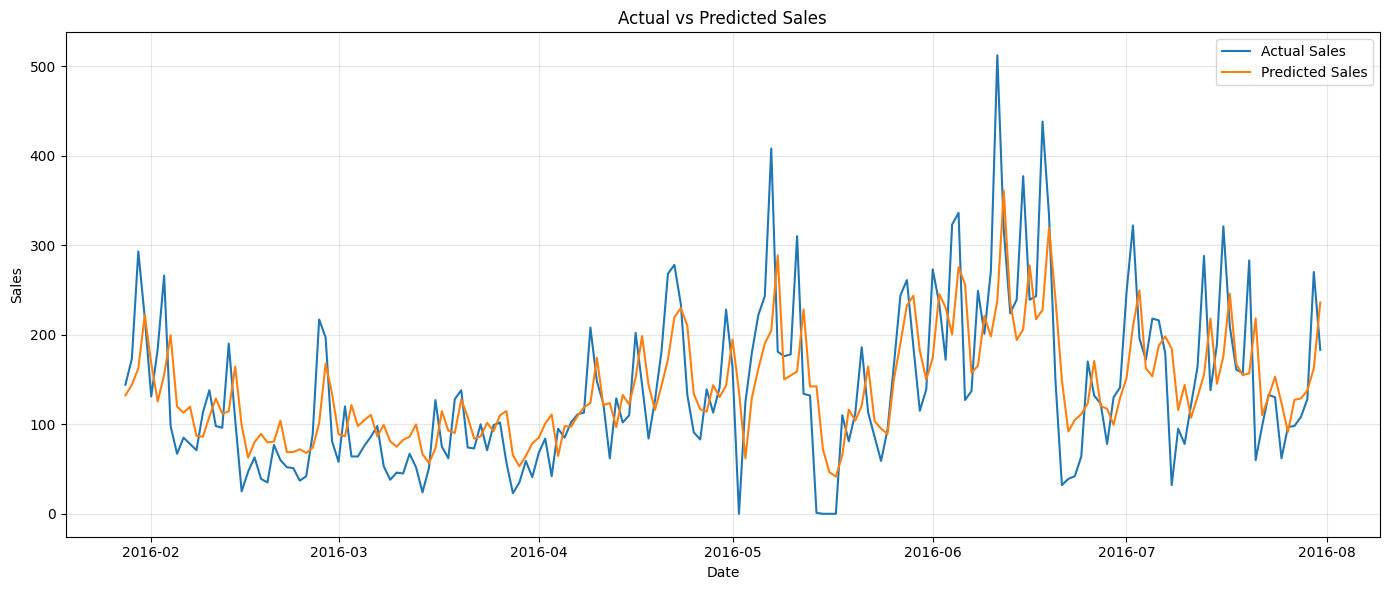

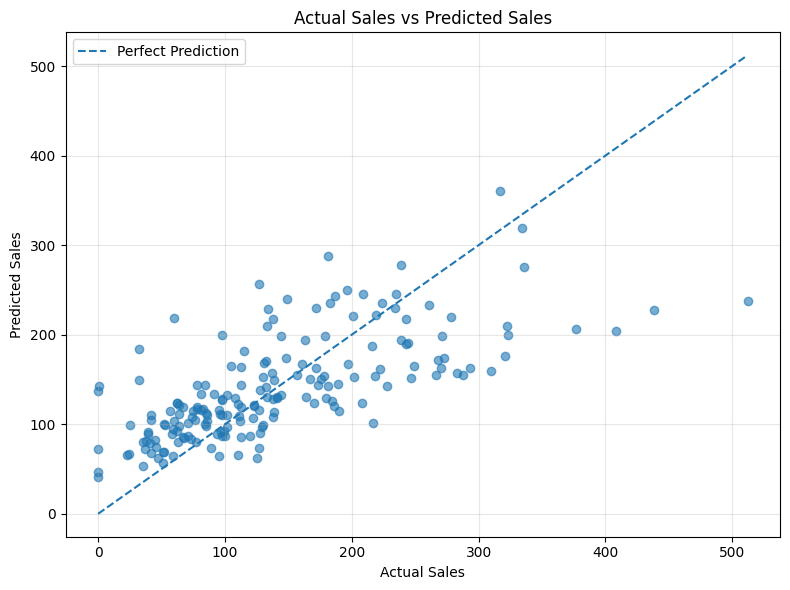

In [31]:
# -----------------------------------------------------------------------------
# STEP 12. ACTUAL VS PREDICTED VISUALIZATION
# -----------------------------------------------------------------------------
plt.figure(figsize=(14, 6))
plt.plot(df_model["Date"].iloc[split_index:], y_test.values,
         label="Actual Sales")
plt.plot(df_model["Date"].iloc[split_index:], y_pred,
         label="Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Regression relationship
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)

line_min = min(y_test.min(), y_pred.min())
line_max = max(y_test.max(), y_pred.max())
plt.plot([line_min, line_max], [line_min, line_max],
         linestyle="--", label="Perfect Prediction")

plt.title("Actual Sales vs Predicted Sales")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

---

## Step 12 - Actual vs Predicted Visualization
The program compares actual sales with predicted sales over the test period.

A good model should produce predictions that follow the actual sales pattern reasonably well.

A second scatter plot compares:
- X-axis: Actual Sales
- Y-axis: Predicted Sales

Points close to the diagonal line indicate smaller prediction errors.

---


STEP 13 - RESIDUAL ANALYSIS
Mean residual: -1.3681
Residual std : 64.9894


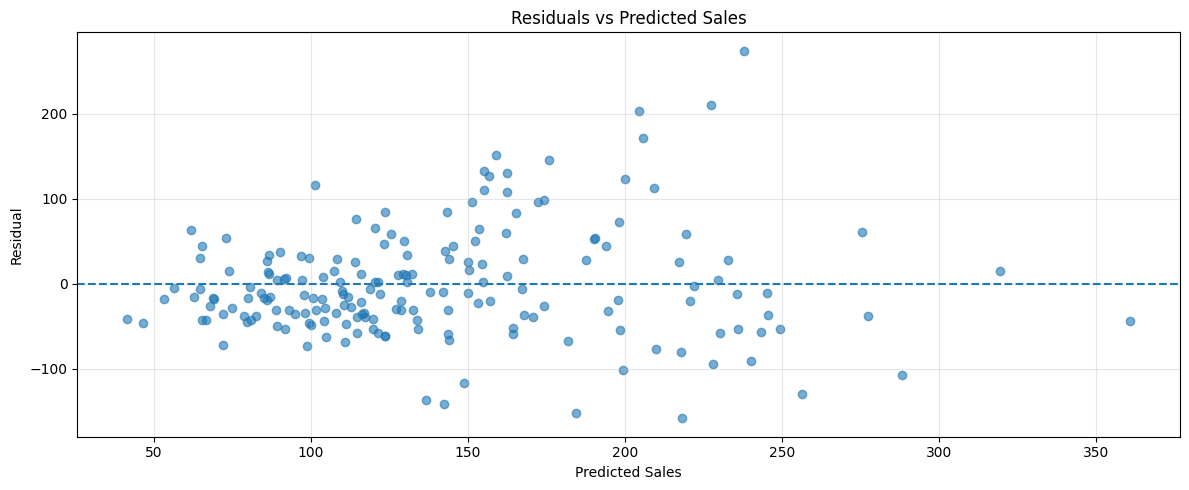

In [32]:
# -----------------------------------------------------------------------------
# STEP 13. RESIDUAL ANALYSIS
# -----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("STEP 13 - RESIDUAL ANALYSIS")
print("=" * 80)

residuals = y_test.values - y_pred

print("Mean residual:", round(residuals.mean(), 4))
print("Residual std :", round(residuals.std(), 4))

plt.figure(figsize=(12, 5))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.title("Residuals vs Predicted Sales")
plt.xlabel("Predicted Sales")
plt.ylabel("Residual")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## Step 13 - Residual Analysis
Residual:

\[
Residual = Actual - Predicted
\]

Residual plots help identify:
- Systematic errors
- Outliers
- Non-linear patterns
- Changing error variance

Ideally, residuals should be distributed around zero without a strong visible pattern.

---

In [33]:
# -----------------------------------------------------------------------------
# STEP 14. FUTURE SALES FORECAST
# -----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("STEP 14 - FUTURE SALES FORECAST")
print("=" * 80)

# Forecast horizon can be changed.
FORECAST_DAYS = 30

history = df[["Date", "Sales", "Stock", "Price"]].copy()

# For future dates, the model uses historical sales lags and calendar features.
# Since future stock/price are unknown, their most recent observed values are
# carried forward as a simple baseline assumption.
last_date = history["Date"].max()
last_stock = history["Stock"].iloc[-1]
last_price = history["Price"].iloc[-1]

future_rows = []

sales_history = history["Sales"].tolist()

for i in range(1, FORECAST_DAYS + 1):
    future_date = last_date + pd.Timedelta(days=i)

    lag_1 = sales_history[-1]
    lag_7 = sales_history[-7] if len(sales_history) >= 7 else sales_history[0]
    rolling_7 = np.mean(sales_history[-7:])

    row = {
        "Sales_Lag_1": lag_1,
        "Sales_Lag_7": lag_7,
        "Sales_Rolling_7": rolling_7,
        "Stock_Lag_1": last_stock,
        "Price_Lag_1": last_price,
        "Year": future_date.year,
        "Month": future_date.month,
        "DayOfWeek": future_date.dayofweek,
        "DayOfMonth": future_date.day,
        "Quarter": future_date.quarter
    }

    predicted_sales = max(0, float(model.predict(pd.DataFrame([row])[features])[0]))

    future_rows.append({
        "Date": future_date,
        "Forecast_Sales": predicted_sales
    })

    # Recursive forecasting: next prediction becomes the next lag value.
    sales_history.append(predicted_sales)

forecast_df = pd.DataFrame(future_rows)

print("\n30-day sales forecast:")
print(forecast_df.to_string(index=False))

print("\nTotal forecast sales:", round(forecast_df["Forecast_Sales"].sum(), 2))
print("Average daily forecast:", round(forecast_df["Forecast_Sales"].mean(), 2))


STEP 14 - FUTURE SALES FORECAST

30-day sales forecast:
      Date  Forecast_Sales
2016-08-01      175.782944
2016-08-02      178.769668
2016-08-03      185.819814
2016-08-04      195.047874
2016-08-05      205.394297
2016-08-06      216.943539
2016-08-07      224.683297
2016-08-08      204.525640
2016-08-09      199.151562
2016-08-10      200.851483
2016-08-11      205.909241
2016-08-12      212.526730
2016-08-13      219.835377
2016-08-14      227.364473
2016-08-15      206.181549
2016-08-16      199.670384
2016-08-17      200.353748
2016-08-18      204.554501
2016-08-19      210.466649
2016-08-20      217.204860
2016-08-21      224.336098
2016-08-22      202.829897
2016-08-23      196.046060
2016-08-24      196.500745
2016-08-25      200.512228
2016-08-26      206.269658
2016-08-27      212.882716
2016-08-28      219.913954
2016-08-29      198.326915
2016-08-30      191.477125

Total forecast sales: 6140.13
Average daily forecast: 204.67


---

## Step 14 - Future Sales Forecast
The trained regression model is used to forecast the next 30 days.

The forecast uses:
- Recent historical sales
- 7-day sales history
- Rolling sales average
- Recent stock
- Recent price
- Calendar variables

The forecast is recursive: each predicted sales value can be used as a future lag value.

### Important assumption
Future stock and price are not known in the historical CSV. Therefore, the example carries the latest observed stock and price forward.

For a production forecasting system, future planned:
- Prices
- Promotions
- Holidays
- Inventory
- Store information
- Product information

should be supplied whenever available.

---

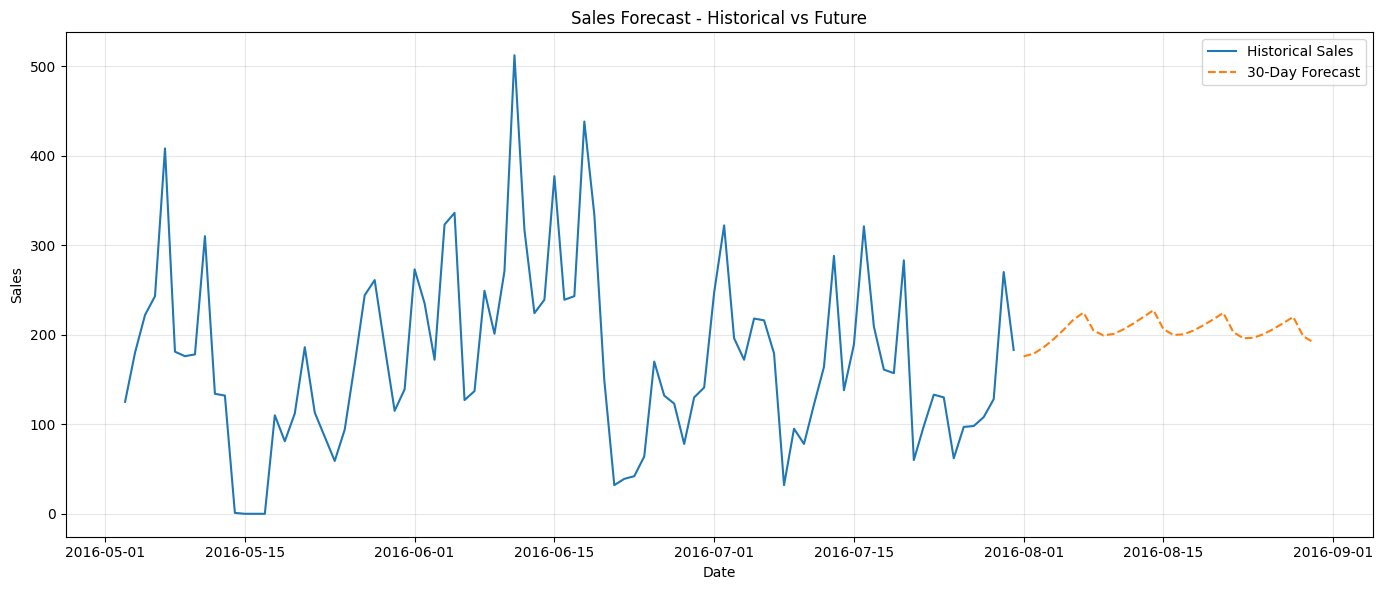

In [34]:
# -----------------------------------------------------------------------------
# STEP 15. FORECAST VISUALIZATION
# -----------------------------------------------------------------------------
plt.figure(figsize=(14, 6))

recent_history = df.tail(90)

plt.plot(recent_history["Date"], recent_history["Sales"],
         label="Historical Sales")
plt.plot(forecast_df["Date"], forecast_df["Forecast_Sales"],
         linestyle="--", label="30-Day Forecast")

plt.title("Sales Forecast - Historical vs Future")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## Step 15 - Forecast Visualization
A line chart displays:
- Recent historical sales
- Future 30-day forecast

This gives the business a visual view of expected demand.


In [35]:
# -----------------------------------------------------------------------------
# STEP 16. BUSINESS CONCLUSION
# -----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("STEP 16 - BUSINESS CONCLUSION")
print("=" * 80)

print(f"""
1. The dataset contains {len(df):,} cleaned daily observations.
2. Average daily sales: {df["Sales"].mean():.2f}.
3. Maximum observed daily sales: {df["Sales"].max():.2f}.
4. Linear Regression R² on the chronological test set: {r2:.4f}.
5. Average forecast sales for the next {FORECAST_DAYS} days:
   {forecast_df["Forecast_Sales"].mean():.2f} units/day.

Business use:
- Forecasts can support inventory replenishment decisions.
- Higher expected sales can trigger earlier restocking.
- Lower expected sales can reduce over-stocking risk.
- Forecast accuracy should be monitored as new transaction data becomes available.

Important assumption:
Future stock and price are unknown in advance, so this demonstration carries
the latest observed stock and price forward. In production, planned prices,
promotions, holidays, store information, and inventory constraints should be
included when available.
""")


STEP 16 - BUSINESS CONCLUSION

1. The dataset contains 937 cleaned daily observations.
2. Average daily sales: 90.53.
3. Maximum observed daily sales: 542.00.
4. Linear Regression R² on the chronological test set: 0.4777.
5. Average forecast sales for the next 30 days:
   204.67 units/day.

Business use:
- Forecasts can support inventory replenishment decisions.
- Higher expected sales can trigger earlier restocking.
- Lower expected sales can reduce over-stocking risk.
- Forecast accuracy should be monitored as new transaction data becomes available.

Important assumption:
Future stock and price are unknown in advance, so this demonstration carries
the latest observed stock and price forward. In production, planned prices,
promotions, holidays, store information, and inventory constraints should be
included when available.



---

## Step 16 - Business Conclusion
The results can support:
- Inventory planning
- Replenishment scheduling
- Demand planning
- Stock-out prevention
- Over-stocking reduction
- Sales planning

The model should be retrained regularly as new sales data becomes available.